In [2]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
tips = sns.load_dataset("tips")
bill = tips["total_bill"].values
tip = tips["tip"].values

In [3]:
def local_weight(x0, X, tau):
    return np.exp(np.sum((X - x0) ** 2, axis=1) / (-2 * tau * tau))

In [4]:
def local_regression(x, X, y, tau):
    y_pred = np.zeros(len(x))

    for i in range(len(x)):
        weights = local_weight(x[i], X, tau)
        W = np.diag(weights)

        theta = np.linalg.pinv(X.T @ W @ X) @ (X.T @ W @ y)
        y_pred[i] = x[i] @ theta

    return y_pred

In [5]:
X = np.c_[np.ones(len(bill)), bill]

xsort = np.sort(bill)
Xsort = np.c_[np.ones(len(xsort)), xsort]

ysort = local_regression(Xsort, X, tip, tau=0.5)

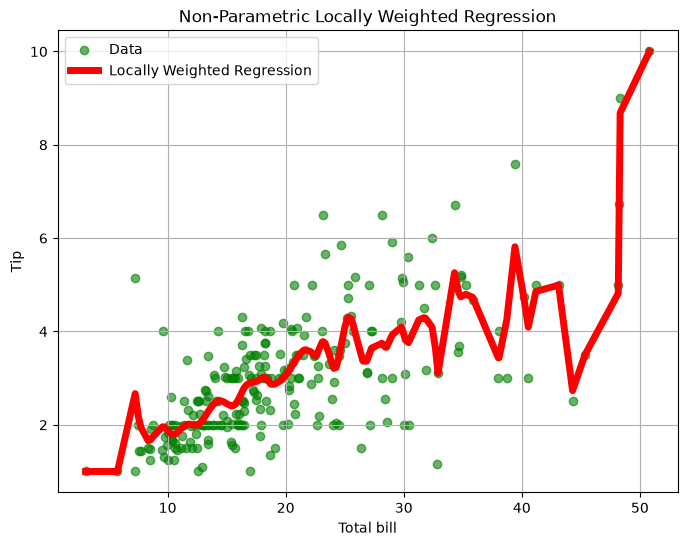

In [6]:
plt.figure(figsize=(8,6))

plt.scatter(bill, tip, color="green", alpha=0.6, label="Data")
plt.plot(xsort, ysort, color="red", linewidth=5,
         label="Locally Weighted Regression")

plt.xlabel("Total bill")
plt.ylabel("Tip")
plt.title("Non-Parametric Locally Weighted Regression")
plt.legend()
plt.grid(True)
plt.show()